# **AI Agent with RAG**

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `ai_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install -q langchain-openai langchain-community chromadb langchain-chroma langchain-tavily tavily-python pymupdf

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import SystemMessage, AIMessage, HumanMessage
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader, PyMuPDFLoader, CSVLoader
from langchain_text_splitters import CharacterTextSplitter

### (3) API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/ai_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])
print(os.environ['TAVILY_API_KEY'][:40])

## **2. Agent with RAG① : RAG를 tool로 사용**
* RAG를 tool로 사용하는 방식

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

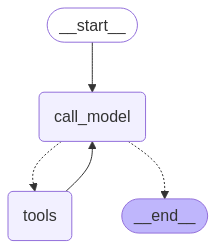

### (1) Vector DB 준비

In [ ]:
# 지식 로딩
pdf_path = "롯데쇼핑 서비스 이용약관.pdf"
pdf_loader = PyMuPDFLoader(path + pdf_path)
doc_pdf = pdf_loader.load()

# 분할
text_splitter = CharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap  = 100,
    separator = '\n',   # \n 줄바꿈 문자 기준으로 자르기,
)

split_docs = text_splitter.split_documents(doc_pdf)

# 벡터 DB 정의
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
db = Chroma.from_documents(split_docs, embedding,
                                    persist_directory= "db01")

### (2) Tool 정의 및 Tool Node 준비

In [ ]:
def rag_search_tool(query: str) -> str:
    "롯데쇼핑 고객 이용 약관 내용 검색시 사용"    # docstring : 도구 설명
    docs = db.similarity_search(query, k=3)

    # 검색된 문서 내용들을 하나의 문자열로 반환
    return "\n\n".join(d.page_content for d in docs)

rag_search_tool('회원가입')

In [ ]:
# 검색 함수 정의
@tool   # 데코레이터
def rag_search_tool(query: str) -> str:
    "롯데 쇼핑 고객 이용 약관 내용 검색시 사용"    # docstring : 도구 설명
    docs = db.similarity_search(query, k=3)

    # 검색된 문서 내용들을 하나의 문자열로 반환
    return "\n\n".join(d.page_content for d in docs)

# tool 노드 준비
tools = [rag_search_tool]
tool_node = ToolNode(tools)

### (3) State 정의 및 LLM 준비(Tool 바인딩)

In [ ]:
class SimpleState(MessagesState):
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini").bind_tools(tools)

### (4) 노드 준비

In [ ]:
# GPT 호출 노드
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성
    sys_msg = SystemMessage("""
    # 역할
    롯데 쇼핑 고객 문의에 답변하는 에이전트야.

    # 지침
    - 사용자의 질문에 rag_search_tool 을 사용해서 문서를 검색한 후 답변해줘.
    - 검색된 문서에 없는 내용은 모른다고 말해.
    """)

    # 3. llm 호출
    result = llm.invoke([sys_msg] + state["messages"])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

### (5) 그래프 구성

In [ ]:
# 그래프 구성
builder = StateGraph(SimpleState)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)          # RAG 도구 노드

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition,
                              {'tools':'tools', '__end__': END})   # tool_use → tools, 아니면 END
builder.add_edge("tools", "chatbot")          # 도구 실행 후 다시 chatbot 으로

graph = builder.compile()

* 그래프 시각화

In [ ]:
graph

### (6) 실행

In [ ]:
initial_state = {"messages": [HumanMessage("LangGraph는 무엇인가요?")]}

result = graph.invoke(initial_state)

for message in result["messages"]:
    message.pretty_print()

### (7) 실습🔥: 검색 도구 추가
* 기존 에이전트에 웹 검색 도구(tavily)를 포함

* 구글검색 도구 준비

In [ ]:
from langchain_tavily import TavilySearch



In [ ]:
# 도구 리스트


# 툴 실행 노드


* LLM+Tool 바인딩

* 노드 준비

In [ ]:
# GPT 호출 노드
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성


    # 3. llm 호출


    # 4. state 업데이트


* 그래프 구성

In [ ]:
from langgraph.checkpoint.memory import MemorySaver


In [ ]:
# 그래프 구성


* 그래프 시각화

In [ ]:
graph

* 실행

In [ ]:
thread_1 = {"configurable": {"thread_id": "1"}}

In [ ]:
initial_state = {"messages": "롯데 멤버십 회원 가입하려면?"}
result = graph.invoke(initial_state, thread_1)

for m in result["messages"]:
    m.pretty_print()

In [ ]:
initial_state = {"messages": "추가 절차에 대해서 안내해줘."}
result = graph.invoke(initial_state, thread_1)

for m in result["messages"]:
    m.pretty_print()

* 메모리 붙여서 테스트
* 시스템 메세지 보완

## **3. Agent with RAG② : RAG를 node로 사용**
* 항상 RAG에서 검색 결과를 기반으로 답변하도록 구성

### (1) Vector DB 준비
* 기존 DB 사용

### (2) DB 검색 함수 준비

In [ ]:
def rag_search(query: str):
    # 검색
    docs = db.similarity_search(query, k=3)

    # 검색 결과를 하나의 텍스트로 합쳐서 return
    return "\n\n".join(d.page_content for d in docs)

### (3) State 정의 및 LLM 준비

In [ ]:
class SimpleState(MessagesState):
    response: str

In [ ]:
# 도구 바인딩이 아닌 일반 llm으로 선언
llm = ChatOpenAI(model = "gpt-4.1-mini")

### (4) 노드 준비

In [ ]:
def rag_chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    query = state["messages"][-1].content

    # RAG 검색
    search_result = rag_search(query)

    # 2. prompt 구성
    sys_msg = SystemMessage(f"""
    # 역할
    롯데쇼핑 멤버십 고객 문의에 답변하는 에이전트야.

    # 지침
    - 사용자 질문과, 아래 검색 결과를 참조하여 답해
    - 질문과 검색 결과가 일치 하지 않으면, 너의 지식으로 추론하지 말고 모른다고 답해

    # 검색결과
    {search_result}
    """)

    # 3. llm 호출
    result = llm.invoke([sys_msg] + state["messages"])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

### (5) 그래프 구성

In [ ]:
builder = StateGraph(SimpleState)

builder.add_node("rag_chatbot", rag_chatbot)

builder.add_edge(START, "rag_chatbot")
builder.add_edge("rag_chatbot", END)

graph = builder.compile()

* 그래프 시각화

In [ ]:
graph

### (6) 실행

In [ ]:
initial_state = {"messages": [HumanMessage("LangGraph는 무엇인가요?")]}

result = graph.invoke(initial_state)

for message in result["messages"]:
    message.pretty_print()

### (7) 실습🔥: 유사도 거리 기준
* 검색시 L2 거리(유사도)가 너무 큰 경우 제외하기

* 검색 결과에 대한 유사도 거리 값을 확인
    * 자주 사용될 만한 질문을 던져서 Score 값의 분포가 어떤지 확인해 봅시다.
    * k = 5

In [ ]:
query = "롯데 멤버십 가입"




In [ ]:
query = '''어제 우리 어머니가 롯데 자이언츠가 경기에 이겨서 기분이 좋으신지,
롯데 멤버십 가입하고 싶다고하셔. 내가 도와드리려고 하는데, 가입하려면 어떻게해?'''



* 적절한 기준을 직접 세우고, 거리를 넘어가는 지식은 검색되지 않도록 검색함수 수정

In [ ]:
def rag_search(query, threshold, k=3):
    text_list = []
    results = db.similarity_search_with_score(query, k=k)

    for doc, score in results :
        if score <= threshold :
            text_list.append(doc.page_content)

    if len(text_list) == 0 :
        return ''

    return '\n\n'.join(text_list)

In [ ]:
result = tavily_tool.invoke(query)
result

In [ ]:
# 구글 검색
def tavily_search(query):
    results = tavily_tool.invoke(query)

    # 검색 결과 텍스트로 정리
    if isinstance(results, list):
        search_text = "\n\n".join([
            r["content"] if isinstance(r, dict) else str(r)
            for r in results
        ])
    else:
        search_text = str(results)

    return search_text[:1000]

* 시스템 메시지에 이에 대한 지침 추가

In [ ]:
def rag_chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장


    # RAG 검색


    # 2. prompt 구성


    # 3. llm 호출


    # 4. state 업데이트


* 그래프 구성 후 테스트

In [ ]:
initial_state = {"messages": "롯데 멤버십 회원 가입하려면?"}
result = graph.invoke(initial_state, thread_1)

for m in result["messages"]:
    m.pretty_print()

In [ ]:
initial_state = {"messages": "롯데마트 이용시간은?"}
result = graph.invoke(initial_state, thread_1)

for m in result["messages"]:
    m.pretty_print()

* [추가] 구글 검색도 추가합시다.
* 메모리 추가
